# Placeholder

Name the files names in the order you expect the TA to see their output. 

```
assignment-1/part-A.ipynb

assignment-1/part-B.ipynb
```

In the above example the TA will see the output of `assignment-1/part-A.ipynb` first, then `assignment-1/part-B.ipynb` to grade your assignment 1. If there is a part that itself is a folder, name the subfolder as `part-A` or `part-B` and put the files inside it.



In [122]:
import torch

device = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")
if torch.cuda.is_available():
    print(torch.cuda.current_device())
    print(torch.cuda.device_count())
    print(torch.cuda.get_device_name(0))

device


0
1
NVIDIA GeForce RTX 3080 Ti


device(type='cuda', index=0)

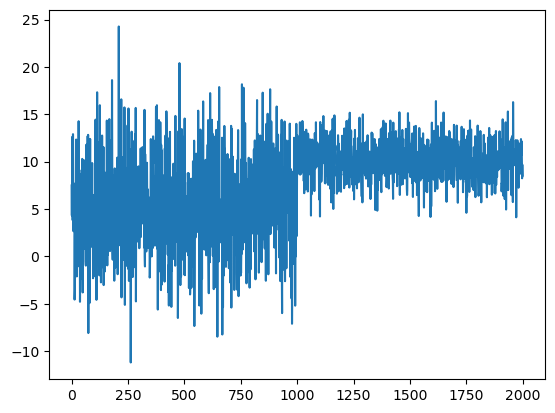

In [123]:
from sklearn import mixture
import matplotlib.pyplot as plt
import numpy as np
import scipy.stats as stats

# Create data from two normal distributions
x = np.concatenate((np.random.normal(5, 5, 1000), np.random.normal(10, 2, 1000)))
plt.plot(x)

[0.49692762 0.22249045 0.28058193]
[[10.65362427]
 [ 1.1653451 ]
 [ 7.36258414]]
[[ 5.10274511]
 [10.48052993]
 [ 5.68781954]]


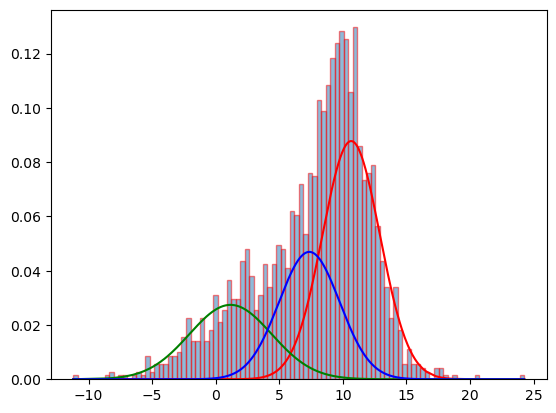

In [124]:
f = x.reshape(-1, 1)
# Decompose data into 3 Gaussians.
g = mixture.GaussianMixture(n_components=3, covariance_type="diag")
g.fit(f)
weights = g.weights_
print(weights)
means = g.means_
print(means)
covars = g.covariances_
print(covars)
x_axis = x
x_axis.sort()

plt.hist(f, bins=100, histtype="bar", density=True, ec="red", alpha=0.5)
plt.plot(x_axis, weights[0] * stats.norm.pdf(x_axis, means[0], np.sqrt(covars[0])).ravel(), c="red")
plt.plot(x_axis, weights[1] * stats.norm.pdf(x_axis, means[1], np.sqrt(covars[1])).ravel(), c="green")
plt.plot(x_axis, weights[2] * stats.norm.pdf(x_axis, means[2], np.sqrt(covars[2])).ravel(), c="blue")

In [125]:
import torch
import torch.distributions as dist
import matplotlib.pyplot as plt
import numpy as np
from matplotlib.patches import Ellipse

# Set random seeds for reproducibility
torch.manual_seed(42)
np.random.seed(42)

# Generate the dataset from known parameters

m = 1000  # m = 1000 sample points
feature_dims = 2  # 2 feature dimensions, x and y
n_components = 3  # Number of Gaussian components

mixing_weights = torch.ones(n_components) / n_components # Uniform distribution, which will be 1/3 for each component
# mixing_weights = torch.tensor([0.3, 0.5, 0.2]) If we want to use the counter-example's weights

# Random means for each component
means = torch.randn(n_components, feature_dims)


# We are defining the shape of the distribution
# By defining it manually, or make it random

'''
covariance_diagonals = torch.tensor(
    [
        [0.5, 0.5],  # Circular
        [3.0, 0.5],  # Wide in x, narrow in y
        [0.5, 3.0],  # Narrow in x, wide in y
    ],
    dtype=torch.float32,
)
'''
covariance_diagonals = torch.abs(torch.randn(n_components, feature_dims)) + 0.5

# Convert diagonal values to full covariance matrices
# We will have zeroes on non-diagonal values in the full covariances
covariances = torch.zeros(n_components, feature_dims, feature_dims)
for i in range(n_components):
    covariances[i] = torch.diag(covariance_diagonals[i])

print("Mixture Parameters:")
print(f"Mixing weights: {mixing_weights}\n")
print(f"Means:\n{means}\n")
print(f"Covariance diagonals:\n{covariance_diagonals}\n")
print(f"Full covariances:\n{covariances}\n")

Mixture Parameters:
Mixing weights: tensor([0.3333, 0.3333, 0.3333])

Means:
tensor([[ 0.3367,  0.1288],
        [ 0.2345,  0.2303],
        [-1.1229, -0.1863]])

Covariance diagonals:
tensor([[2.7082, 1.1380],
        [0.9617, 0.7674],
        [1.0349, 1.3094]])

Full covariances:
tensor([[[2.7082, 0.0000],
         [0.0000, 1.1380]],

        [[0.9617, 0.0000],
         [0.0000, 0.7674]],

        [[1.0349, 0.0000],
         [0.0000, 1.3094]]])



In [126]:
# Step 2: Create PyTorch distributions
def create_mixture_distributions(means, covariances, mixing_weights):
    """Create PyTorch distribution objects for the mixture"""

    # Create individual multivariate normal distributions
    components = []
    for i in range(len(means)):
        component = dist.MultivariateNormal(means[i], covariances[i])
        components.append(component)

    # Create categorical distribution for component selection
    component_dist = dist.Categorical(mixing_weights)

    return components, component_dist


# Create the distributions
components, component_dist = create_mixture_distributions(means, covariances, mixing_weights)

print(f"\nCreated {len(components)} component distributions")


Created 3 component distributions


In [ ]:
# Step 3: Generate the dataset using PyTorch sampling
def sample_from_mixture(m, components, component_dist):
    """Sample from mixture of Gaussians using PyTorch"""

    # Sample which component each data point comes from
    # Note: Tensor of (m,) is a 1D tensor with m elements, where m = 1000
    component_indices = component_dist.sample((m,)) # Result: tensor of m integers, each in range [0, n_components-1]
    # e.g., [0, 2, 1, 0, 1, 2, ...]

    # Initialize output tensors
    samples = torch.zeros(m, feature_dims) # Shape: (1000, 2) Tensor with 2 feature dimensions

    # Sample from each component
    for i in range(len(components)):
        # Find which samples should come from component i
        # The mask will return true for each element that is i
        # Given i = 0:
        # [0, 2, 1, 0, 1, 2, ...] ->  [T, F, F, T, F, F, ...]
        mask = (component_indices == i) 
        n_from_component = mask.sum().item() # True counts as 1 in .sum(), then .item() converts from tensor to python num
        print(f"n_from_component: {i, n_from_component}")
        if n_from_component > 0:
            # Sample from component i
            # component_samples might look like:
            # tensor([[0.87, 2.13],   # Random point near mean [1.0, 2.0]
            #         [1.23, 1.92],   # Another random point
            #         [0.95, 2.31],   # Another random point
            #         ...             # 350 more points
            #         [1.11, 1.88]])  # Point 354
            component_samples = components[i].sample((n_from_component,))
            # Places points from component_samples into the correct position as indicated by the mask
            samples[mask] = component_samples

    # Return all 1000 xy coordinates, and which sample they are from: e.g., [0, 2, 1, 0, 1, 2, ...]
    return samples, component_indices


# Generate the dataset
# X will - the actual data points(features), 1000 samples with 2 features each. (x,y coordinates)
# y_truth - the ground truth labels, it indicates which component each point came from
X, y_true = sample_from_mixture(m, components, component_dist)

print(f"\nGenerated dataset:")
print(f"Shape: {X.shape}")
print(f"Data type: {X.dtype}")
print(f"Device: {X.device}")

print(f"\nGround truth:")
print(f"Shape: {y_true.shape}")
# Due to the randomness of sampling, we won't get 333 exactly for each component
print(f"Component distribution: {torch.bincount(y_true)}")

n_from_component: (0, 354)
n_from_component: (1, 337)
n_from_component: (2, 309)

Generated dataset:
Shape: torch.Size([1000, 2])
Data type: torch.float32
Device: cpu

Ground truth:
Shape: torch.Size([1000])
Component distribution: tensor([354, 337, 309])


In [128]:
# Step 4: Verify our generation by computing statistics
print(f"\nDataset Statistics:")
print(f"Overall mean: [{X[:, 0].mean():.3f}, {X[:, 1].mean():.3f}]")
print(f"Overall std:  [{X[:, 0].std():.3f}, {X[:, 1].std():.3f}]")

print(f"\nPer-component statistics:")
for i in range(n_components):
    mask = (y_true == i)
    component_data = X[mask]
    print(f"Component {i}: {mask.sum().item()} samples")
    print(f"  Mean: [{component_data[:, 0].mean():.3f}, {component_data[:, 1].mean():.3f}]")
    print(f"  Std:  [{component_data[:, 0].std():.3f}, {component_data[:, 1].std():.3f}]")


Dataset Statistics:
Overall mean: [-0.179, 0.073]
Overall std:  [1.437, 1.021]

Per-component statistics:
Component 0: 354 samples
  Mean: [0.307, 0.116]
  Std:  [1.657, 1.047]
Component 1: 337 samples
  Mean: [0.212, 0.219]
  Std:  [1.006, 0.871]
Component 2: 309 samples
  Mean: [-1.162, -0.135]
  Std:  [1.020, 1.110]


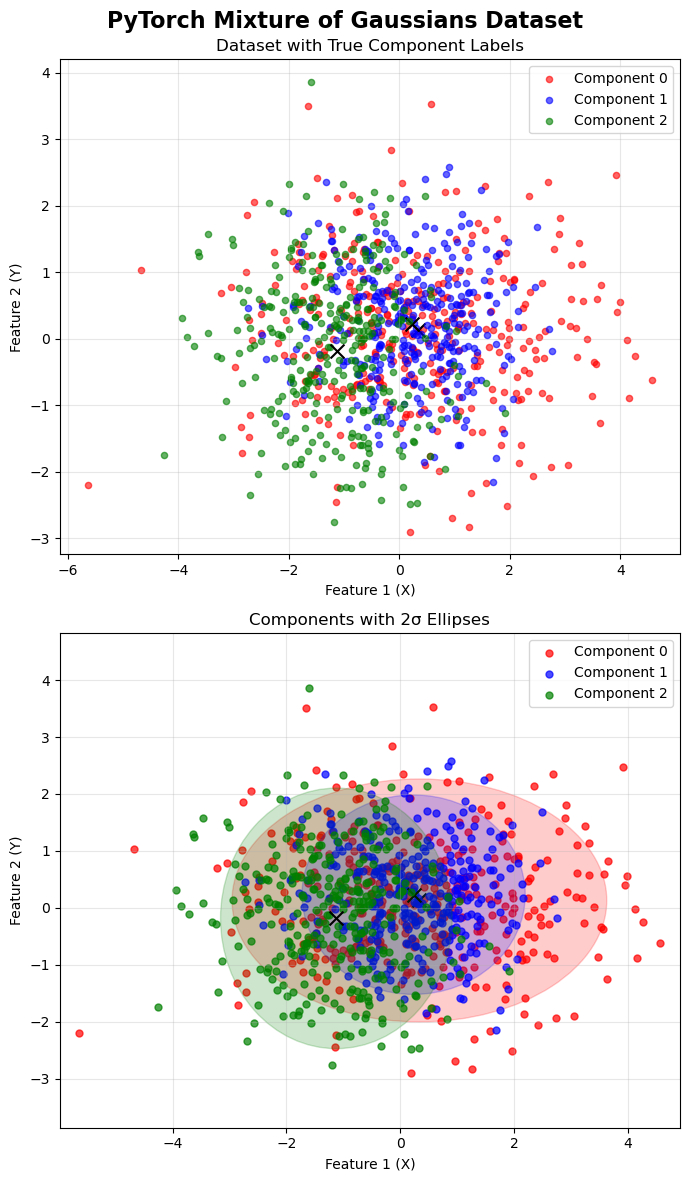

In [ ]:
# Step 5: Visualization

# Convert to numpy for easier plotting and analysis
X_np = X.numpy()
y_true_np = y_true.numpy()

fig, axes = plt.subplots(2, 1, figsize=(7, 12))
fig.suptitle("PyTorch Mixture of Gaussians Dataset", fontsize=16, fontweight="bold")

colors = ["red", "blue", "green"]
component_names = ["Component 0", "Component 1", "Component 2"]

# Plot 1: Scatter plot with 3 components
ax1 = axes[0]
for i in range(n_components):
    mask = y_true_np == i
    ax1.scatter(X_np[mask, 0], X_np[mask, 1], c=colors[i], alpha=0.6, label=component_names[i], s=20)
    # Mark true means
    ax1.scatter(means[i, 0], means[i, 1], c="black", marker="x", s=100)

ax1.set_title("Dataset with True Component Labels")
ax1.set_xlabel("Feature 1 (X)")
ax1.set_ylabel("Feature 2 (Y)")
ax1.legend()
ax1.grid(True, alpha=0.3)


# Plot 2: Components with covariance ellipses
ax2 = axes[1]
for i in range(n_components):
    mask = y_true_np == i
    ax2.scatter(X_np[mask, 0], X_np[mask, 1], c=colors[i], alpha=0.7, label=component_names[i], s=25)

    # Draw 2-sigma ellipses
    cov_matrix = covariances[i].numpy()
    eigenvals, eigenvecs = np.linalg.eigh(cov_matrix)
    angle = np.degrees(np.arctan2(eigenvecs[1, 0], eigenvecs[0, 0]))
    width, height = 2 * np.sqrt(eigenvals) * 2  # 2-sigma

    ellipse = Ellipse(
        means[i].numpy(), width, height, angle=angle, facecolor=colors[i], alpha=0.2, edgecolor=colors[i]
    )
    ax2.add_patch(ellipse)

    # Mark means
    ax2.scatter(means[i, 0], means[i, 1], c="black", marker="x", s=100)

ax2.set_title("Components with 2σ Ellipses")
ax2.set_xlabel("Feature 1 (X)")
ax2.set_ylabel("Feature 2 (Y)")
ax2.legend()
ax2.grid(True, alpha=0.3)
ax2.axis("equal")

plt.tight_layout()
plt.show()
